Objective:
The objective of this project is to perform text
cleaning, analysis, and visualization on the Amazon
Reviews dataset. Preprocessing the text data,
performing exploratory analysis, extracting insights from
the reviews, and visualizing the findings to gain a better
understanding of the dataset

In [8]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Loading the dataset
df=pd.read_csv(r"/content/7817_1.csv")

In [10]:
# Checking the head of the data
df.head()

,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


In [11]:
# no. of columns and rows in data
df.shape

(1597, 27)

In [12]:
df.columns

Index(['id', 'asins', 'brand', 'categories', 'colors', 'dateAdded',
       'dateUpdated', 'dimension', 'ean', 'keys', 'manufacturer',
       'manufacturerNumber', 'name', 'prices', 'reviews.date',
       'reviews.doRecommend', 'reviews.numHelpful', 'reviews.rating',
       'reviews.sourceURLs', 'reviews.text', 'reviews.title',
       'reviews.userCity', 'reviews.userProvince', 'reviews.username', 'sizes',
       'upc', 'weight'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1597 entries, 0 to 1596
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1597 non-null   object 
 1   asins                 1597 non-null   object 
 2   brand                 1597 non-null   object 
 3   categories            1597 non-null   object 
 4   colors                774 non-null    object 
 5   dateAdded             1597 non-null   object 
 6   dateUpdated           1597 non-null   object 
 7   dimension             565 non-null    object 
 8   ean                   898 non-null    float64
 9   keys                  1597 non-null   object 
 10  manufacturer          965 non-null    object 
 11  manufacturerNumber    902 non-null    object 
 12  name                  1597 non-null   object 
 13  prices                1597 non-null   object 
 14  reviews.date          1217 non-null   object 
 15  reviews.doRecommend  

In [14]:
df.dtypes

,0
id,object
asins,object
brand,object
categories,object
colors,object
dateAdded,object
dateUpdated,object
dimension,object
ean,float64
keys,object


In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ean,898.0,8.443135e+11,3.416444e+09,8.416670e+11,8.416670e+11,8.416670e+11,8.487190e+11,8.487190e+11
reviews.numHelpful,900.0,8.358444e+01,1.971502e+02,0.000000e+00,0.000000e+00,0.000000e+00,3.400000e+01,9.970000e+02
reviews.rating,1177.0,4.359388e+00,1.021445e+00,1.000000e+00,4.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00
reviews.userCity,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
reviews.userProvince,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sizes,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
upc,898.0,8.443135e+11,3.416444e+09,8.416670e+11,8.416670e+11,8.416670e+11,8.487190e+11,8.487190e+11


In [16]:
df.isnull().sum()

,0
id,0
asins,0
brand,0
categories,0
colors,823
dateAdded,0
dateUpdated,0
dimension,1032
ean,699
keys,0


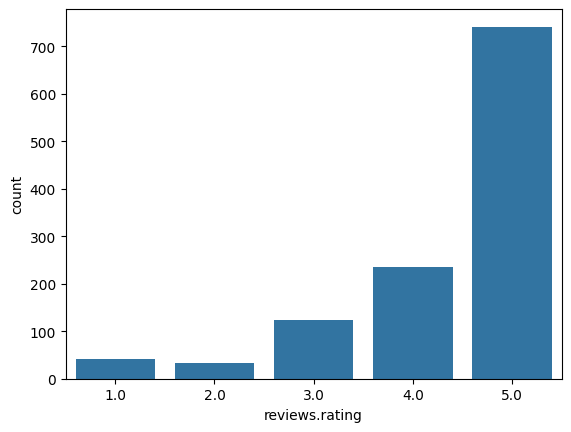

In [17]:
# analysing distiribution of ratings
sns.countplot(x="reviews.rating",data=df)
plt.show()
# Inference : the dataset is strongly positive. Most rated reviews are 4 or 5 stars, especially 5-star reviews

In [18]:
# selecting the relevent columns for sentiment analysis
df=pd.read_csv("/content/7817_1.csv")
df=df[["reviews.text", "reviews.rating"]]
df.head()

,reviews.text,reviews.rating
0,I initially had trouble deciding between the p...,5.0
1,Allow me to preface this with a little history...,5.0
2,I am enjoying it so far. Great for reading. Ha...,4.0
3,I bought one of the first Paperwhites and have...,5.0
4,I have to say upfront - I don't like coroporat...,5.0


In [19]:
# checking null and dropping them to perform sentiment analysis
df=df.dropna(subset=["reviews.text", "reviews.rating"])
df.isnull().sum()

,0
reviews.text,0
reviews.rating,0


In [20]:
# typecasting rating column into integer
df["reviews.rating"]=df["reviews.rating"].astype(int)
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1177 entries, 0 to 1596
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   reviews.text    1177 non-null   object
 1   reviews.rating  1177 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 27.6+ KB


In [21]:
# value counts of positive, negative and neutral sentiment
def get_sentiment(rating):
  if rating>=4:
    return "Positive"
  elif rating==3:
    return "Neutral"
  if rating<=2:
    return "Negative"

df["sentiment"]=df["reviews.rating"].apply(get_sentiment)
df["sentiment"].value_counts()


,count
sentiment,
Positive,977
Neutral,124
Negative,76


In [22]:
df.head()

,reviews.text,reviews.rating,sentiment
0,I initially had trouble deciding between the p...,5,Positive
1,Allow me to preface this with a little history...,5,Positive
2,I am enjoying it so far. Great for reading. Ha...,4,Positive
3,I bought one of the first Paperwhites and have...,5,Positive
4,I have to say upfront - I don't like coroporat...,5,Positive


In [23]:
# tokenisation
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download required NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [24]:
# lemmatize
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if not isinstance(text, str):
        return [] # Return empty list for non-string input
    # a. Remove HTML tags & punctuation/special characters
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # b. Convert to lowercase
    text = text.lower()
    # c. Tokenization
    tokens = word_tokenize(text)
    # Remove stopwords & d. Lemmatize to root form
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    return cleaned_tokens # Return list of tokens

# Apply cleaning to the dataset
df['cleaned_text'] = df['reviews.text'].apply(clean_text)
# Calculate review length for later tasks
df['review_length'] = df['cleaned_text'].apply(lambda x: len(x))

In [25]:
df.head()

,reviews.text,reviews.rating,sentiment,cleaned_text,review_length
0,I initially had trouble deciding between the p...,5,Positive,"[initially, trouble, deciding, paperwhite, voy...",92
1,Allow me to preface this with a little history...,5,Positive,"[allow, preface, little, history, casual, read...",125
2,I am enjoying it so far. Great for reading. Ha...,4,Positive,"[enjoying, far, great, reading, original, fire...",18
3,I bought one of the first Paperwhites and have...,5,Positive,"[bought, one, first, paperwhites, pleased, con...",153
4,I have to say upfront - I don't like coroporat...,5,Positive,"[say, upfront, dont, like, coroporate, hermeti...",183


In [27]:
all_Words = [word for sublist in df['cleaned_text'] for word in sublist]
freq_words=nltk.FreqDist(all_Words).most_common(20)
freq_words

[('amazon', 822),
 ('fire', 772),
 ('like', 744),
 ('kindle', 729),
 ('great', 586),
 ('sound', 574),
 ('use', 564),
 ('one', 563),
 ('tablet', 538),
 ('device', 511),
 ('would', 452),
 ('headphone', 452),
 ('dont', 450),
 ('im', 447),
 ('year', 427),
 ('echo', 420),
 ('review', 419),
 ('tap', 397),
 ('work', 382),
 ('screen', 372)]

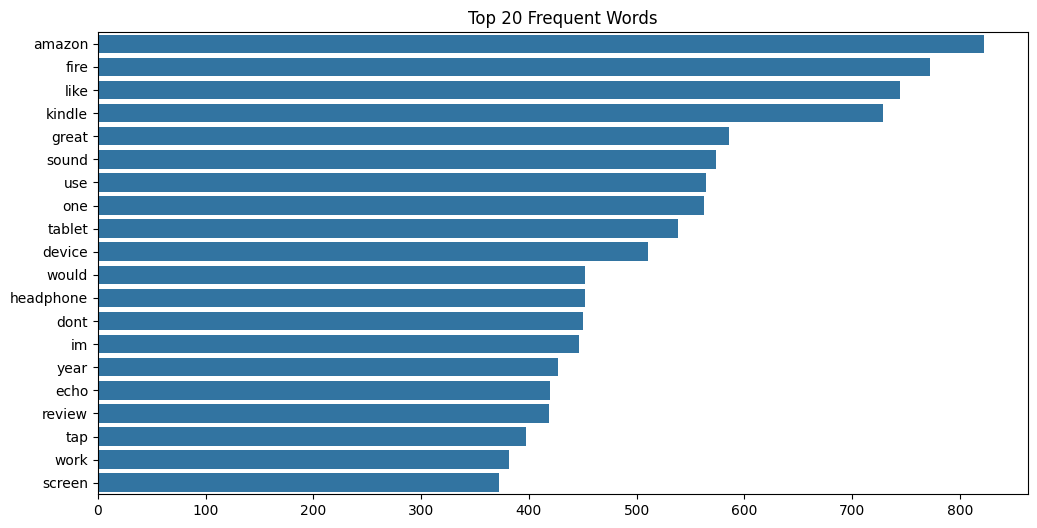

In [28]:
words = [word[0] for word in freq_words]
counts = [word[1] for word in freq_words]

plt.figure(figsize=(12,6))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Frequent Words")
plt.show()

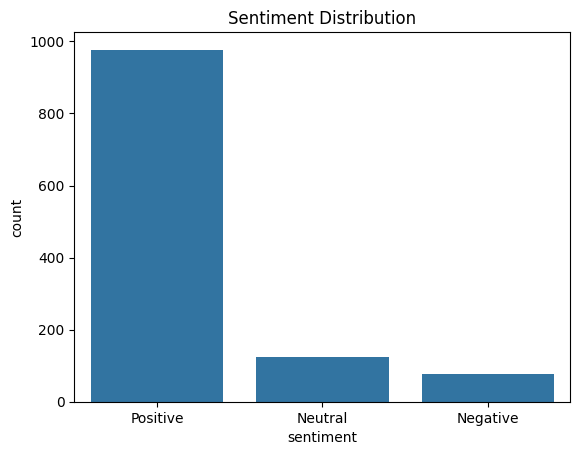

In [29]:
sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

In [30]:
df['review_length'] = df['cleaned_text'].apply(len)
df.head()

,reviews.text,reviews.rating,sentiment,cleaned_text,review_length
0,I initially had trouble deciding between the p...,5,Positive,"[initially, trouble, deciding, paperwhite, voy...",92
1,Allow me to preface this with a little history...,5,Positive,"[allow, preface, little, history, casual, read...",125
2,I am enjoying it so far. Great for reading. Ha...,4,Positive,"[enjoying, far, great, reading, original, fire...",18
3,I bought one of the first Paperwhites and have...,5,Positive,"[bought, one, first, paperwhites, pleased, con...",153
4,I have to say upfront - I don't like coroporat...,5,Positive,"[say, upfront, dont, like, coroporate, hermeti...",183


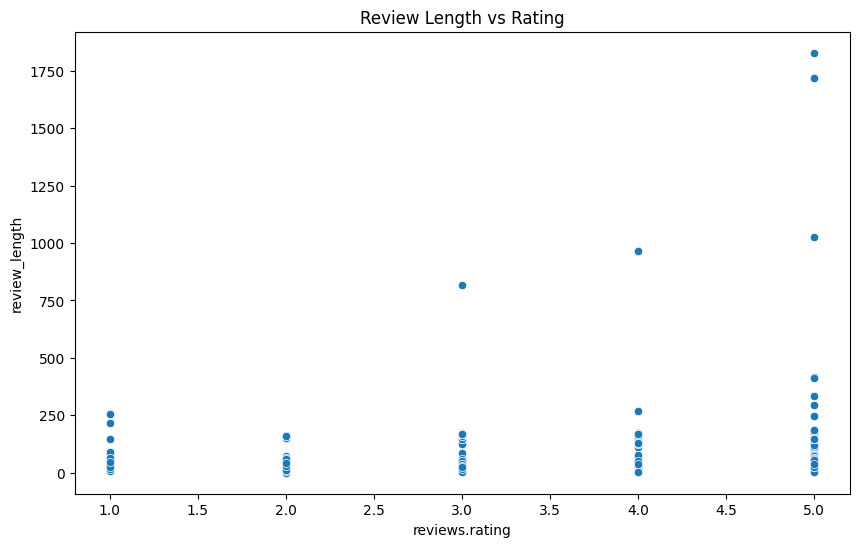

In [31]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='reviews.rating', y='review_length', data=df)
plt.title("Review Length vs Rating")
plt.show()

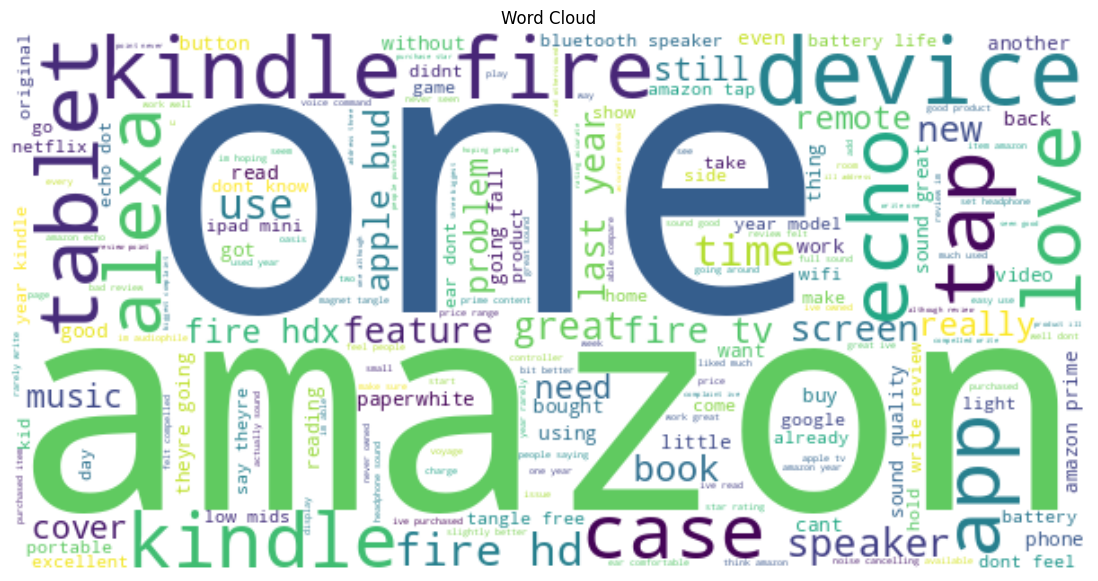

In [34]:
from wordcloud import WordCloud
# The previous error occurred because 'df['cleaned_text']' contained lists of words,
# and ' '.join expects an iterable of strings.
# The 'all_Words' variable from a previous cell already contains a flattened list of all words.
all_words = ' '.join(all_Words)

wordcloud = WordCloud(
    width=600,
    height=300,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

In [35]:
# LDA - Advanced Analysis
!pip install gensim
import sklearn
from sklearn.decomposition import LatentDirichletAllocation
import gensim
from gensim import corpora

# Create the dictionary from the cleaned text
dictionary = corpora.Dictionary(df['cleaned_text'])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 60.3 MB/s eta 0:00:00


In [36]:
from gensim.models import LdaModel

word_corpus=[dictionary.doc2bow(text) for text in df['cleaned_text']]
lda_model = LdaModel(
    corpus=word_corpus,
    id2word=dictionary,
    num_topics=5,
    passes=10
)

In [37]:
topics = lda_model.print_topics()

for topic in topics:
    print(topic)

(0, '0.024*"kindle" + 0.023*"fire" + 0.013*"tablet" + 0.012*"hdx" + 0.011*"hd" + 0.011*"year" + 0.011*"device" + 0.011*"amazon" + 0.009*"new" + 0.009*"screen"')
(1, '0.019*"im" + 0.016*"review" + 0.015*"sound" + 0.014*"dont" + 0.013*"apple" + 0.013*"headphone" + 0.013*"ive" + 0.012*"like" + 0.011*"amazon" + 0.010*"well"')
(2, '0.012*"like" + 0.011*"tablet" + 0.010*"cover" + 0.009*"case" + 0.008*"look" + 0.008*"would" + 0.008*"screen" + 0.008*"great" + 0.007*"want" + 0.007*"kindle"')
(3, '0.015*"tv" + 0.011*"like" + 0.011*"headphone" + 0.010*"remote" + 0.010*"amazon" + 0.010*"use" + 0.009*"prime" + 0.008*"really" + 0.008*"dont" + 0.007*"ear"')
(4, '0.022*"tap" + 0.019*"echo" + 0.017*"speaker" + 0.015*"great" + 0.014*"alexa" + 0.013*"amazon" + 0.012*"love" + 0.012*"sound" + 0.011*"use" + 0.011*"music"')


In [40]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.cluster import KMeans
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df['cleaned_text'].apply(lambda x: ' '.join(x)))
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
kmeans.fit(X)
df['cluster'] = kmeans.labels_
df['cluster'].value_counts()

,count
cluster,
1,1170
2,6
0,1


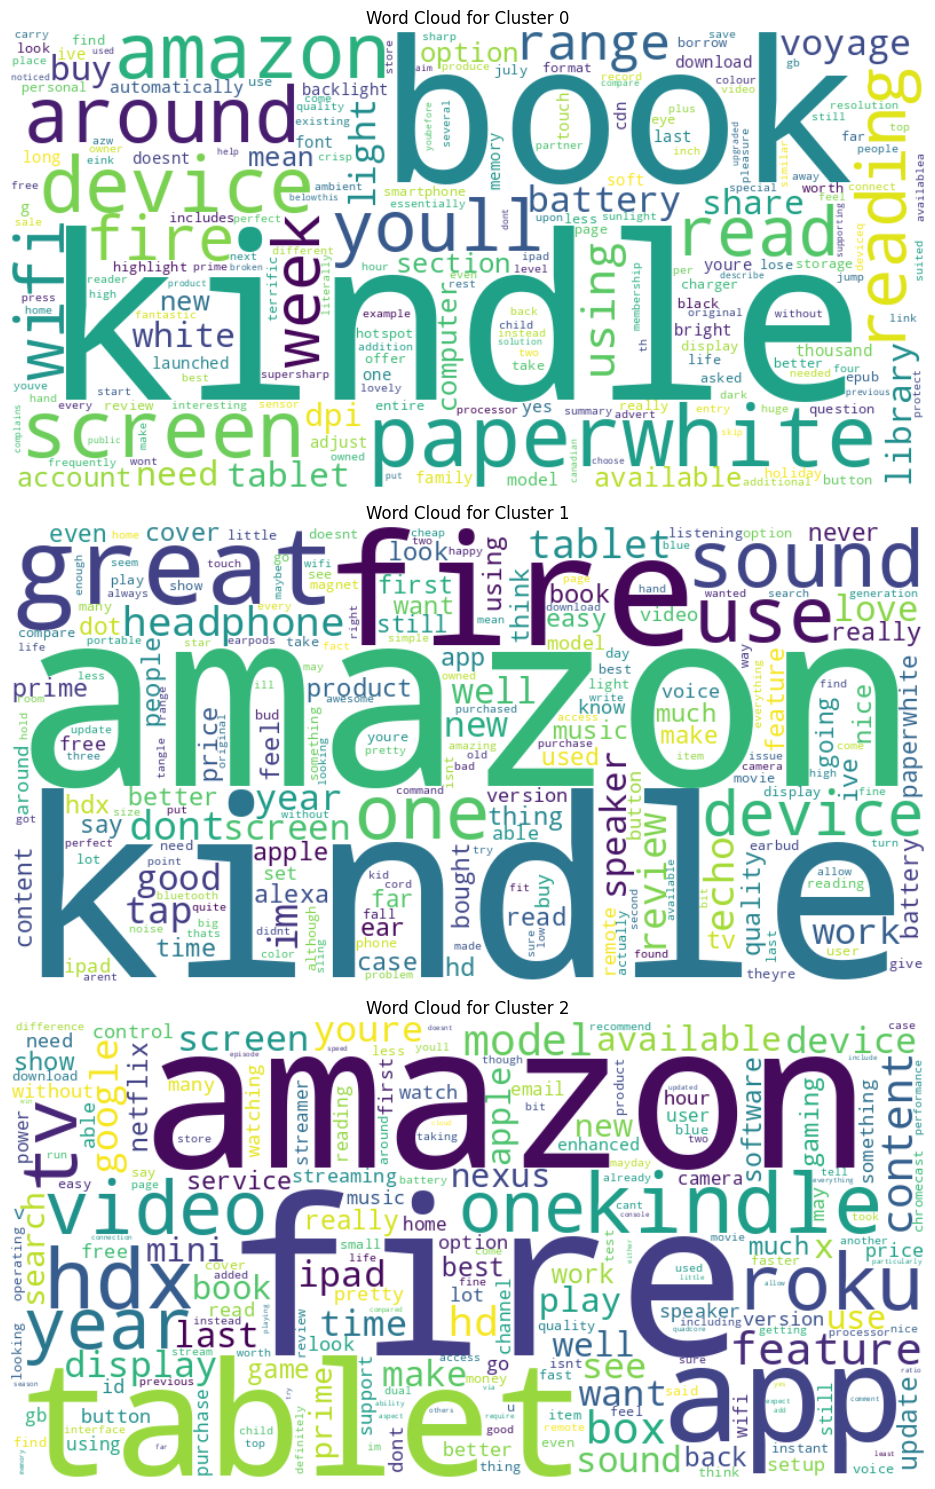

In [48]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

unique_clusters = df['cluster'].unique()

plt.figure(figsize=(15, 5 * len(unique_clusters)))

for i, cluster_label in enumerate(sorted(unique_clusters)):
    cluster_reviews = df[df['cluster'] == cluster_label]


    all_words_in_cluster = ' '.join([' '.join(text_list) for text_list in cluster_reviews['cleaned_text']])

    if not all_words_in_cluster:
        print(f"Cluster {cluster_label} has no words to display.")
        continue

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        collocations=False
    ).generate(all_words_in_cluster)

    plt.subplot(len(unique_clusters), 1, i + 1)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Cluster {cluster_label}')

plt.tight_layout()
plt.show()



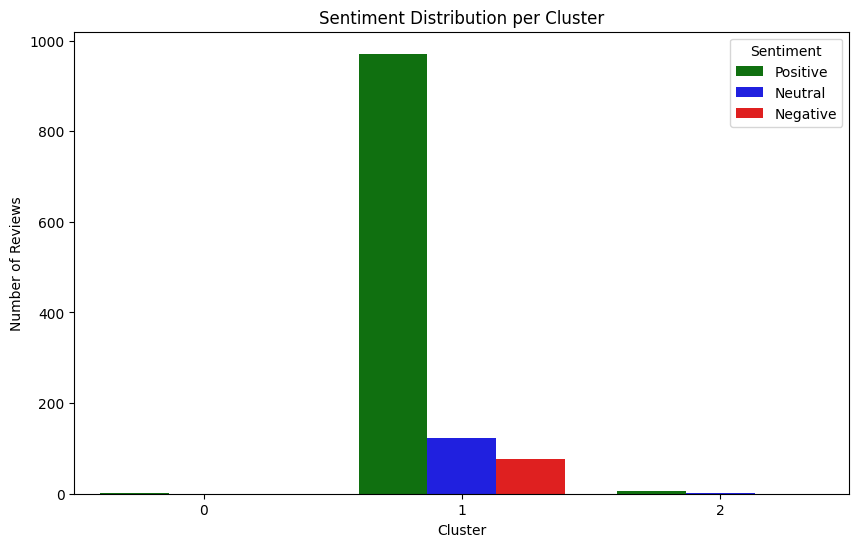

In [43]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='cluster', hue='sentiment', palette={'Positive': 'green', 'Neutral': 'blue', 'Negative': 'red'})
plt.title('Sentiment Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.show()

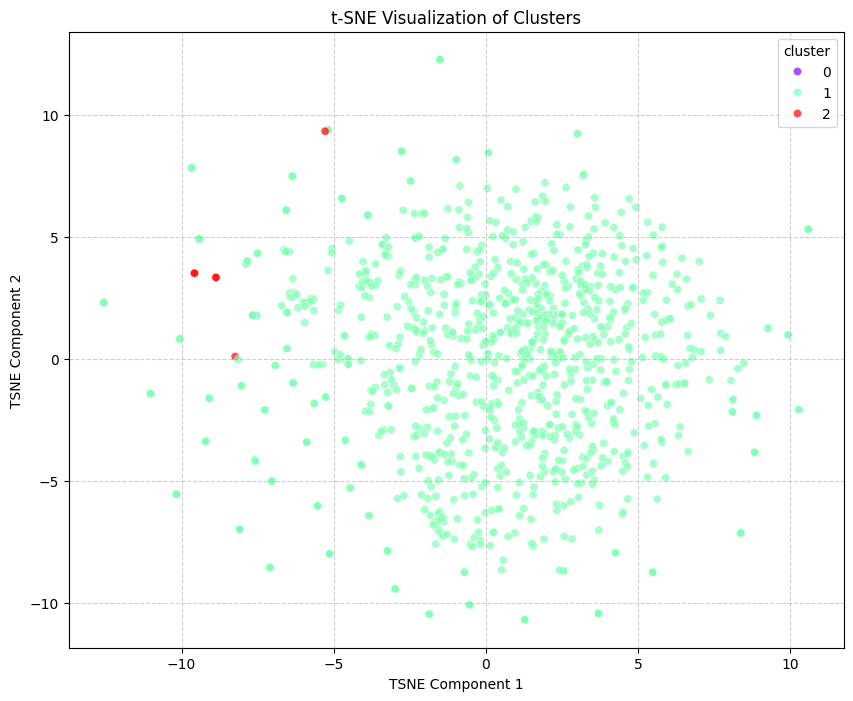

In [49]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=300)
X_tsne = tsne.fit_transform(X.toarray())

df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
df_tsne['cluster'] = df['cluster'].reset_index(drop=True)


plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='TSNE1', y='TSNE2',
    hue='cluster',
    palette='rainbow',
    data=df_tsne,
    legend='full',
    alpha=0.7
)
plt.title('t-SNE Visualization of Clusters')
plt.xlabel('TSNE Component 1')
plt.ylabel('TSNE Component 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [50]:
print(df.groupby('cluster')['review_length'].describe())

          count         mean         std     min     25%     50%     75%  \
cluster                                                                    
0           1.0  1026.000000         NaN  1026.0  1026.0  1026.0  1026.0   
1        1170.0    60.886325   64.484319     0.0    11.0    26.0   135.0   
2           6.0  1334.500000  464.871057   816.0   964.0  1340.5  1717.0   

            max  
cluster          
0        1026.0  
1         415.0  
2        1829.0  
